#  Energy Consumption Modeling for UAVs Based on Flight Data and Mission Parameters :
## 1. Data analysis and feature extraction

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

In [2]:
from utils import clean_flight_df, plot_flight_altitude_speed, MAE, RMSE, MAPE

### M100 Data

In [3]:
df = pd.read_csv(r"C:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)
cols = df.columns.tolist()

C:\Users\raman\AppData\Local\Temp\ipykernel_18156\2046151961.py:1: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\12683453\flights.csv", delimiter=",", encoding="utf-8", header=0)


### Data Cleaning

Sanity check

In [4]:
clean_df = clean_flight_df(df)

c:\Users\raman\Desktop\Kanchan_Material\01_AirTransportAndLogistics\Course_Material\Semester_03\Research Task\utils.py:245: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_day'] = pd.to_datetime(df['time_day'], errors='coerce').dt.time


### Find different phase of flight using  altitude, horizontal and vertical speed. 

In [5]:
df = df.sort_values(["flight", "time"]).reset_index(drop=True)
df["altitude_measured"] = df["position_z"] - df.groupby("flight")["position_z"].transform("first")
df["horizontal_speed"] = np.sqrt(df["velocity_x"]**2 + df["velocity_y"]**2)
df['alt_diff'] = df.groupby('flight')['altitude_measured'].diff()
df['max_altitude_flight'] = df.groupby('flight')['altitude_measured'].transform('max')
df['min_altitude_flight'] = df.groupby('flight')['altitude_measured'].transform('min')

df["dt"] = df.groupby("flight")["time"].diff()

df["vz_from_alt_raw"] = df["alt_diff"] / df["dt"]

df["vz_from_alt"] = (
    df.groupby("flight")["vz_from_alt_raw"]
      .transform(lambda x: x.rolling(window=10, center=True, min_periods=1).mean())
)

### Velocity from altitude diff and velocity_z are not same e.g. in 120
So lets do a sanity check.

In [6]:
# Select flights to inspect
flights_to_plot = [120, 79, 279]   # add more flight numbers here if you like
sub = df[df["flight"].isin(flights_to_plot)].copy()

# Prepare data for Plotly (melt to long format for nice legends)
plot_df = sub.melt(
    id_vars=["flight", "time"],
    value_vars=["velocity_z", "vz_from_alt"],
    var_name="source",
    value_name="vz"
)

# Plot both velocities over time, faceted by Flight
fig = px.line(
    plot_df,
    x="time",
    y="vz",
    color="source",
    facet_row="flight",        # or facet_col="flight" if you prefer columns
    title="Reported vs Altitude-derived Vertical Velocity",
    labels={
        "time": "Time",
        "vz": "Vertical velocity (m/s)",
        "source": "Signal source"
    }
)

fig.update_layout(height=300*len(flights_to_plot))  # adjust height for number of flights
fig.show()

#### Definitions of various phases

In [83]:

# Thresholds
NEARLY_ZERO_HORIZONTAL_VEL   = 0.3   # m/s 
NEARLY_ZERO_VERTICAL_VEL     = 0.2   # m/s

CRUISE_MAX_VERTICAL_VEL    = 0.6   # m/s
CRUISE_MIN_VERTICAL_VEL    = -0.6  # m/s

TAXI_ALTITUDE_MAX      = 1   # m   # max altitude to be considered taxiing

# Start with a default phase
df['phase'] = 'other'

# --- Taxi: low altitude, nearly no motion ---
taxi_mask = (
    (df['horizontal_speed'].abs() < NEARLY_ZERO_HORIZONTAL_VEL) &
    (df['vz_from_alt'].abs()      < NEARLY_ZERO_VERTICAL_VEL) &
    (df['altitude_measured']      < TAXI_ALTITUDE_MAX)
)
df.loc[(df['phase'] == 'other') & taxi_mask, 'phase'] = 'taxi'


# --- Hover: nearly no motion ---
# 1. horizontal speed below hover max
# 2. vertical speed below hover max
hover_mask = (
    (df['horizontal_speed'].abs() < NEARLY_ZERO_HORIZONTAL_VEL) &
    (df['vz_from_alt'].abs()      < NEARLY_ZERO_VERTICAL_VEL) 
)
df.loc[(df['phase'] == 'other') & hover_mask, 'phase'] = 'hover'

# --- Cruise: nearly no vertical motion, high altitude ---
# 1. vertical speed below cruise max
# 2. altitude above 80% of max altitude in flight
cruise_mask = (
    (df['vz_from_alt'] < CRUISE_MAX_VERTICAL_VEL) &
    (df['vz_from_alt'] > CRUISE_MIN_VERTICAL_VEL) &
    (df['altitude_measured'] > 0.8 * df['max_altitude_flight'])
)
df.loc[(df['phase'] == 'other') & cruise_mask, 'phase'] = 'cruise'

# ---- CLIMB ----
# 1. vertical speed is greater than climb vertical speed minimum
climb_mask = (df['vz_from_alt'] > CRUISE_MAX_VERTICAL_VEL)
df.loc[(df['phase'] == 'other') & climb_mask, 'phase'] = 'climb'

# ---- DESCENT ----
# 1. vertical speed is less than negative of climb vertical speed minimum
descent_mask = (df['vz_from_alt'] < CRUISE_MIN_VERTICAL_VEL)
df.loc[(df['phase'] == 'other') & descent_mask, 'phase'] = 'descent'




### Visualize different phase of flight with Line graph

In [85]:
flight_id = 60
d = df[df["flight"] == flight_id].copy()

# ------------------ Define colors for phases ------------------
phase_colors = {
    "climb":   "rgba(0,255,0,0.25)",      # light green
    "descent": "rgba(255,0,0,0.25)",      # light red
    "hover":   "rgba(255,165,0,0.25)",    # light orange
    "cruise":  "rgba(0,0,255,0.25)",      # light blue
    "taxi":    "rgba(255,255,0,0.25)",    # light yellow
    "other":   "rgba(150,150,150,0.15)"   # light gray
}

# ------------------ Build customdata for hover ------------------
customdata = np.stack((
    d["altitude_measured"],
    d["vz_from_alt"],
    d["horizontal_speed"],
    d["phase"]
), axis=-1)

fig = plot_flight_altitude_speed(
    d,
    customdata=customdata,
    phase_colors=phase_colors,
    flight_id=flight_id,
    show=True
)

### Task two
#### Define Parameter

In [87]:
# -------------------------
# Global Parameters
# -------------------------

# Physical constants
rho = 1.225           # air density (kg/m³)
g = 9.81              # gravity (m/s²)

# Drone parameters
mass_kg = 2.36
disc_area_m2 = 0.22   # example rotor disc area
n_rotor = 4              # reference area
rotor_radius = 0.175   # [m] 10-inch propellers
eta_hover = 0.80  

L_over_D_cruise = 4.0    # lift-to-drag ratio in cruise (multicopter ~ 3–5)
eta_cruise      = 0.60   # cruise efficiency (from ATM paper for multicopter)
eta_batt  = 0.95
eta_esc   = 0.97
eta_motor = 0.85
eta_prop  = 0.85   # example

eta_tot = eta_batt * eta_esc * eta_motor * eta_prop
print("Total eta:", eta_tot)

Total eta: 0.6657837499999999


#### Find Hover Power

In [88]:
df.columns

Index(['flight', 'time', 'wind_speed', 'wind_angle', 'battery_voltage',
       'battery_current', 'position_x', 'position_y', 'position_z',
       'orientation_x', 'orientation_y', 'orientation_z', 'orientation_w',
       'velocity_x', 'velocity_y', 'velocity_z', 'angular_x', 'angular_y',
       'angular_z', 'linear_acceleration_x', 'linear_acceleration_y',
       'linear_acceleration_z', 'speed', 'payload', 'altitude', 'date',
       'time_day', 'route', 'altitude_measured', 'horizontal_speed',
       'alt_diff', 'max_altitude_flight', 'min_altitude_flight', 'dt',
       'vz_from_alt_raw', 'vz_from_alt', 'phase', 'power_W'],
      dtype='object')

In [89]:
df["power_W"] = (df["battery_voltage"] * df["battery_current"])

In [90]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Density')

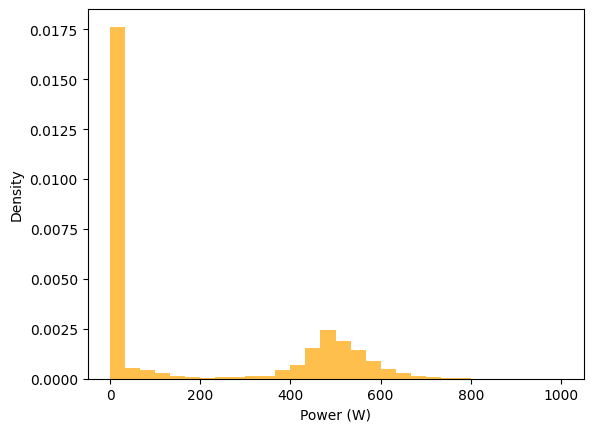

In [91]:
plt.hist(df[df["phase"] == "hover"]["power_W"], density=True, bins=30, alpha=0.7, color='orange', range=(0, 1000))
plt.xlabel("Power (W)")
plt.ylabel("Density")

In [92]:
df_hover = df[df["phase"] == "hover"]

In [93]:
df_hover[df_hover["power_W"]<5]["flight"].unique()

array([  2,   4,  59,  60,  78,  83,  87,  93,  95,  96,  97, 102, 109,
       111, 112, 118, 123, 124, 125, 128, 131, 134, 147, 148, 152, 154,
       155, 158, 163, 164, 169, 173, 174, 177, 180, 181, 183, 188, 189,
       192, 194, 195, 196, 198, 199, 200, 209, 229, 232, 234, 239, 241,
       243, 249, 252, 253, 254, 256, 257, 260, 262, 263, 267, 271, 272,
       276, 278])

In [94]:
df_hover[df_hover["flight"] == 60]["power_W"]

20284    636.828618
20701    116.906445
20702    124.126932
20703    124.830941
20704    127.028361
            ...    
20839      2.298776
20840      1.768489
20841      1.238012
20842      1.768489
20843      1.945009
Name: power_W, Length: 144, dtype: float64

In [99]:
def hover_power():
    W = mass_kg * g
    A = n_rotor * np.pi * (rotor_radius ** 2)     # total rotor disc area
    DL = W / A
    P_hover = (W / eta_hover) * np.sqrt(DL / (2 * rho))
    return P_hover

P_hover_derived = hover_power()
print(f"Hover Power = {P_hover_derived:.3f} watts")

# hover = df[df["phase"] == "hover"].copy()
# print("\nRaw hover samples in df:", len(hover))
# P_measured = hover["power_W"].values  
# print(P_measured)
# df["P_hover_model"] = P_hover_derived / eta_tot

# P_pred = np.full_like(P_measured, df["P_hover_model"].iloc[0], dtype= float)
# mae  = MAE(P_measured, P_pred)
# rmse = RMSE(P_measured, P_pred)
# mape = MAPE(P_measured, P_pred)

# print("Hover - Measured vs Derived")
# print(f"MAE  : {mae:.3f} W")
# print(f"RMSE : {rmse:.3f} W")
# print(f"MAPE : {mape:.2f} %")



Hover Power = 143.402 watts
